In [1]:
import keras 
from sklearn.model_selection import train_test_split

I0000 00:00:1781846547.616714   12403 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781846547.672090   12403 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781846549.484496   12403 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [5]:
(X_train, y_train), (X_test, y_test)  = keras.datasets.fashion_mnist.load_data()


In [17]:
X_train = X_train[:600]
y_train = y_train[:600]

In [18]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_train.shape

(600, 28, 28, 1)

In [19]:
X_test = X_test.reshape(-1, 28, 28, 1)
X_test.shape

(10000, 28, 28, 1)

In [20]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=.2)

In [2]:
from keras.layers  import Input, Dense, Conv2D, Flatten, MaxPooling2D, Dropout

In [3]:
# 모델 만들기 
model = keras.Sequential()
model.add(Input(shape=(28,28,1)))
model.add(Conv2D(filters=32, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling2D(2))
model.add(Conv2D(filters=64, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling2D(2))
model.add(Conv2D(filters=64, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling2D(2))
model.add(Flatten())
model.add(Dense(units=100, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(units=10, activation='softmax'))         

E0000 00:00:1781846876.232008   12403 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1781846876.232260   12476 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1781846876.261784   12403 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        57,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,454 (447.09 KB)

 Trainable params: 114,454 (447.09 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 방법 1
keras.Sequential([
    
]
)

In [ ]:
# 방법 2   Functional API 사용
inputs = 
x =
x = 

outputs = 
keras.Models(inputs, outputs)


In [23]:
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [24]:
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val))

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.3562 - loss: 11.1050 - val_accuracy: 0.6167 - val_loss: 1.0680
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6021 - loss: 1.3505 - val_accuracy: 0.7167 - val_loss: 0.9093
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7125 - loss: 0.9310 - val_accuracy: 0.7500 - val_loss: 0.7737
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7542 - loss: 0.7347 - val_accuracy: 0.7333 - val_loss: 0.7649
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8229 - loss: 0.5873 - val_accuracy: 0.7583 - val_loss: 0.8315
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8062 - loss: 0.5465 - val_accuracy: 0.7667 - val_loss: 1.0339
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8313 - loss: 0.5540 - val_accuracy: 0.7917 - val_loss: 0.7195
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8521 - loss: 0.4175 - val_accuracy: 0.7750 - 

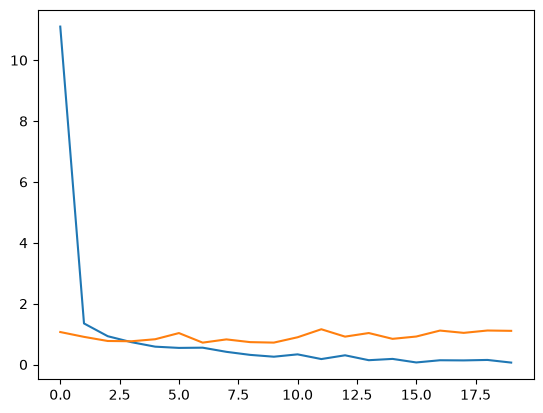

In [26]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [27]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7814 - loss: 1.1848


[1.1848056316375732, 0.7814000248908997]